# Part 1: Exploratory Data Analysis

## The Problem

The attached logins.json file contains (simulated) timestamps of user logins in a particular
geographic location. Aggregate these login counts based on 15 minute time intervals, and
visualize and describe the resulting time series of login counts in ways that best characterize the
underlying patterns of the demand. Please report/illustrate important features of the demand,
such as daily cycles. If there are data quality issues, please report them.

## Goals
- Use longins.json file
- Aggregate counts to every 15 min
- Identify any patterns
- Visualize any patterns
- Identify any cycles within the data (ex. daily, weekly, monthly)
- Identify any issues within the data

## File Summary

Analysis Summary:
The dataset was first checked for any issues and was found to be relatively clean (see Potential Issues below). After data integrity was checked, the data was then modified and binned into 15 min intervals and the total logins every 15 min was used as the dependent variable throughout the rest of the analysis. A general pattern was observed where logins were greatest on the weekend at night while the logins were greatest around 11-12 AM during the week. The login attempts by day were compared using a Tukeys test and Sat and Sun were found to not be significantly different from each other, but were significantly different from all other days (p < 0.001). This may be due to people's workdays so people may only have more time to login during the weekend. 

Potential Issues:
There are a couple data qualtiy issues. First, There are aa total of 877 duplicated login times (0.94% of data overall). This could be from different computers or something else so talking to the data owner would help solve this issue. Another issue is the single datapoint having >70 logins. This could be correct, but worth a double check with the owner. Lastly, There are plenty of times where no logins were logged. This may be fine, but it could relate to system errors. 

### Please see below for figures and data workup.

## Data cleanup and initial analysis

In [1]:
# load relevant libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the data

df = pd.read_json(r"C:\Users\benpe\OneDrive\Documents\GitHub\Projects\1631809090_1481053515_ultimate_challenge_3_ (1)\ultimate_challenge\logins.json")
df.head(10)

,login_time
0,1970-01-01 20:13:18
1,1970-01-01 20:16:10
2,1970-01-01 20:16:37
3,1970-01-01 20:16:36
4,1970-01-01 20:26:21
5,1970-01-01 20:21:41
6,1970-01-01 20:12:16
7,1970-01-01 20:35:47
8,1970-01-01 20:35:38
9,1970-01-01 20:47:52


In [3]:
df.describe()

,login_time
count,93142
mean,1970-02-26 19:09:39.779648278
min,1970-01-01 20:12:16
25%,1970-02-04 10:37:19.750000
50%,1970-03-01 06:33:05.500000
75%,1970-03-22 04:01:10.750000
max,1970-04-13 18:57:38


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93142 entries, 0 to 93141
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   login_time  93142 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 727.8 KB


In [5]:
df.isnull().sum()

login_time    0
dtype: int64

In [6]:
duplicated = df.duplicated().sum()
percent_duplicated = round((duplicated / len(df)) * 100, 2)

print(f" # Duplicated = {duplicated}")
print(f" Total percent of dataset duplicated = {percent_duplicated}%")

# I would want to double check that this is ok with whoever is the data provider. 
# This could be due to some people logging on at the same time which is feasable.
# Generally would remove duplicates form datasets, but I think these may need to stay


 # Duplicated = 877
 Total percent of dataset duplicated = 0.94%


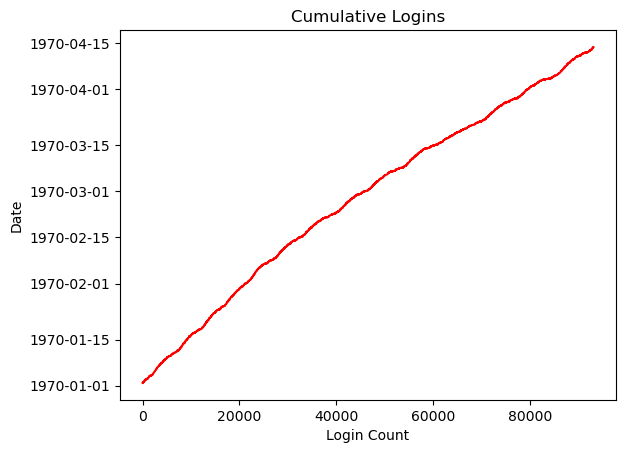

In [7]:
# Want to get a visualization of the data
plt.plot(df, color = 'red')
plt.title("Cumulative Logins")
plt.xlabel("Login Count")
plt.ylabel("Date")
plt.show()

Notes:
- no nulls
- About 3.5 months of data
- inconsitent times for logins (may relate to duplicates)
- 93142 total logins
- Each login has the correct datatype (datetime64)

There are no glaring issues and the data looks to be spread throughotu the range of dates given. Any more analysis would likely be overkill so moving on to the aggregation and following analysis.

In [8]:
# Approach to aggregation: Index should be the time, the resample and count

df_idx = df.set_index('login_time')
df_idx.head()

""
login_time
1970-01-01 20:13:18
1970-01-01 20:16:10
1970-01-01 20:16:37
1970-01-01 20:16:36
1970-01-01 20:26:21


In [9]:
df_15min = df_idx.resample('15min').size()
df_15min.head()

login_time
1970-01-01 20:00:00    2
1970-01-01 20:15:00    6
1970-01-01 20:30:00    9
1970-01-01 20:45:00    7
1970-01-01 21:00:00    1
Freq: 15min, dtype: int64

In [10]:
df_15min = df_15min.reset_index(name='login_count')
df_15min.head()

,login_time,login_count
0,1970-01-01 20:00:00,2
1,1970-01-01 20:15:00,6
2,1970-01-01 20:30:00,9
3,1970-01-01 20:45:00,7
4,1970-01-01 21:00:00,1


In [11]:
df_15min = df_15min.set_index('login_time')
df_15min.head()

,login_count
login_time,
1970-01-01 20:00:00,2
1970-01-01 20:15:00,6
1970-01-01 20:30:00,9
1970-01-01 20:45:00,7
1970-01-01 21:00:00,1


In [12]:
df_15min['display_time'] = df_15min.index.strftime('%m-%d %H:%M')
df_15min['Month'] = df_15min.index.month
df_15min['Day'] = df_15min.index.day
df_15min['hour'] = df_15min.index.hour
df_15min.head()

,login_count,display_time,Month,Day,hour
login_time,,,,,
1970-01-01 20:00:00,2,01-01 20:00,1,1,20
1970-01-01 20:15:00,6,01-01 20:15,1,1,20
1970-01-01 20:30:00,9,01-01 20:30,1,1,20
1970-01-01 20:45:00,7,01-01 20:45,1,1,20
1970-01-01 21:00:00,1,01-01 21:00,1,1,21


In [13]:
df_15min['month_name'] = df_15min.index.strftime('%B')
df_15min['day_name'] = df_15min.index.strftime('%A')

df_15min.tail()

,login_count,display_time,Month,Day,hour,month_name,day_name
login_time,,,,,,,
1970-04-13 17:45:00,5,04-13 17:45,4,13,17,April,Monday
1970-04-13 18:00:00,5,04-13 18:00,4,13,18,April,Monday
1970-04-13 18:15:00,2,04-13 18:15,4,13,18,April,Monday
1970-04-13 18:30:00,7,04-13 18:30,4,13,18,April,Monday
1970-04-13 18:45:00,6,04-13 18:45,4,13,18,April,Monday


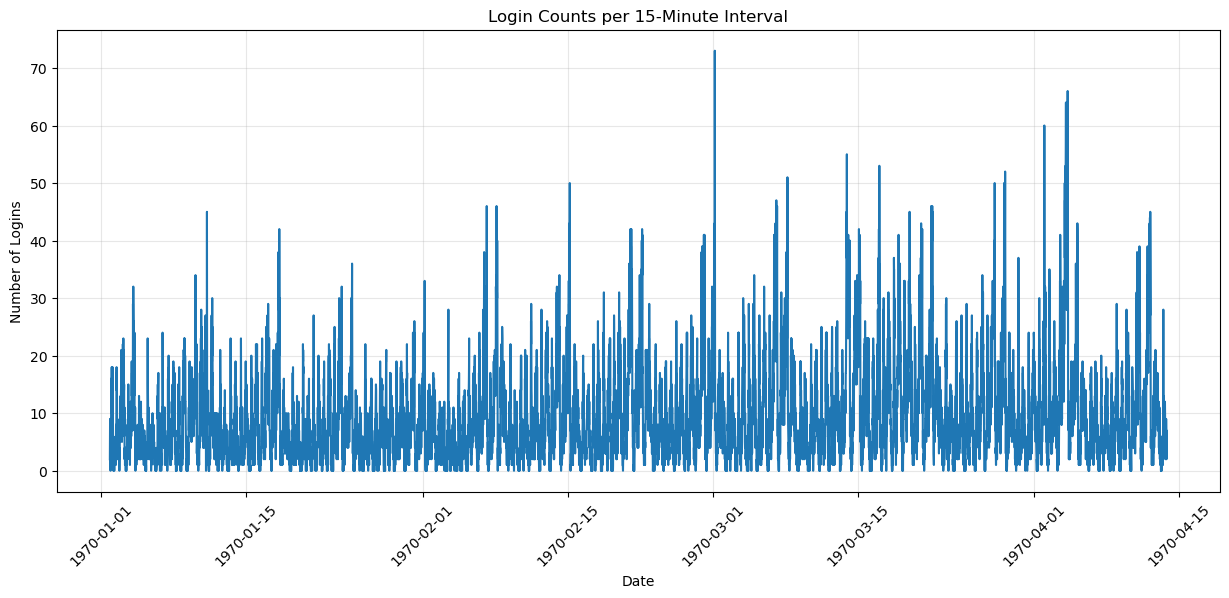

In [14]:
plt.figure(figsize=(15, 6))

plt.plot(df_15min.index, df_15min['login_count'])

plt.title('Login Counts per 15-Minute Interval')
plt.xlabel('Date')
plt.ylabel('Number of Logins')

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

# looks like there are some repetitions, will need to check daily use, weekly use, and monthly use

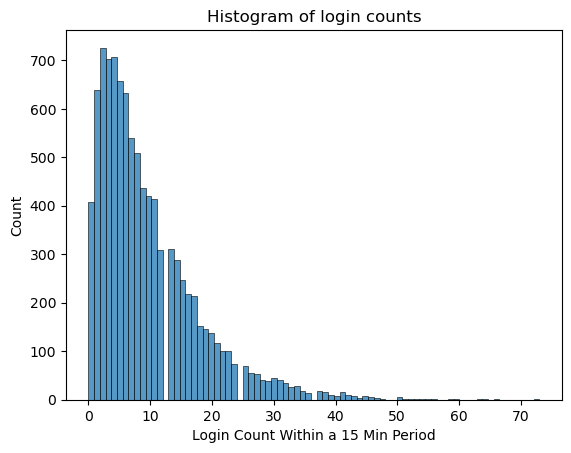

In [15]:
sns.histplot(df_15min['login_count'])
plt.title('Histogram of login counts')
plt.xlabel('Login Count Within a 15 Min Period')
plt.ylabel('Count')
plt.show()

## Hourly Login Check

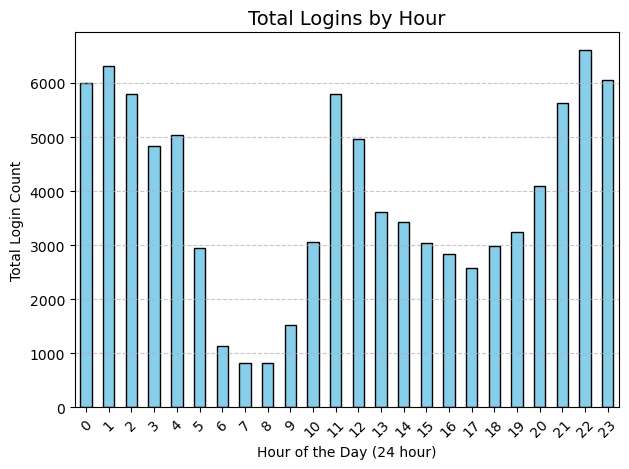

In [16]:
df_hourly = df_15min.groupby('hour')['login_count'].sum()


df_hourly = df_hourly.sort_index()

df_hourly.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Total Logins by Hour', fontsize=14)
plt.xlabel('Hour of the Day (24 hour)')
plt.ylabel('Total Login Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

C:\Users\benpe\AppData\Local\Temp\ipykernel_66372\1403495522.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='hour', y='login_count', data=df_15min, palette='Set2')


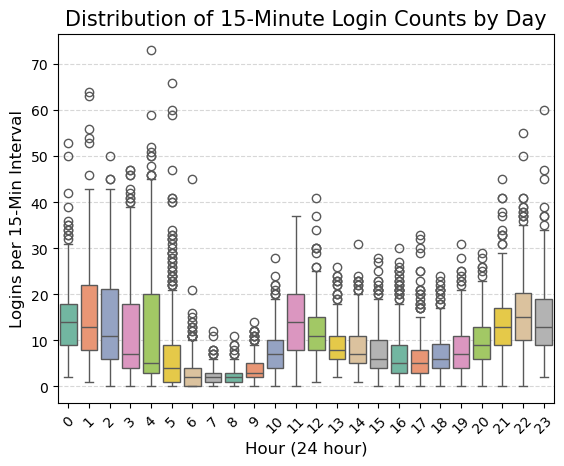

In [17]:
sns.boxplot(x='hour', y='login_count', data=df_15min, palette='Set2')

plt.title('Distribution of 15-Minute Login Counts by Day', fontsize=15)
plt.xlabel('Hour (24 hour)', fontsize=12)
plt.ylabel('Logins per 15-Min Interval', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## Daily Login Check

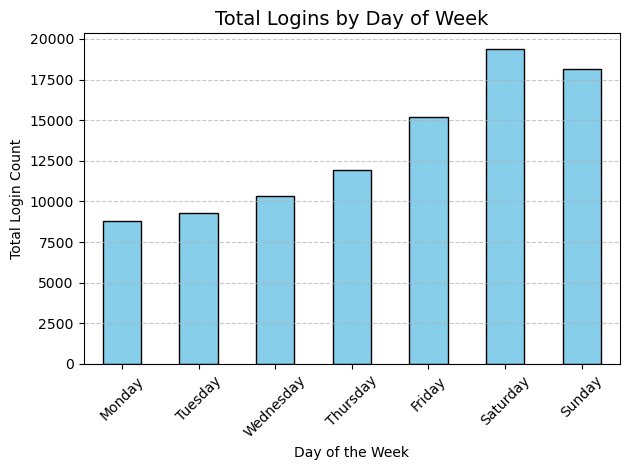

In [18]:
df_daily = df_15min.groupby('day_name')['login_count'].sum()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_daily = df_daily.reindex(day_order)

df_daily.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Total Logins by Day of Week', fontsize=14)
plt.xlabel('Day of the Week')
plt.ylabel('Total Login Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

C:\Users\benpe\AppData\Local\Temp\ipykernel_66372\4176625669.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='day_name', y='login_count', data=df_15min, order=day_order, palette='Set2')


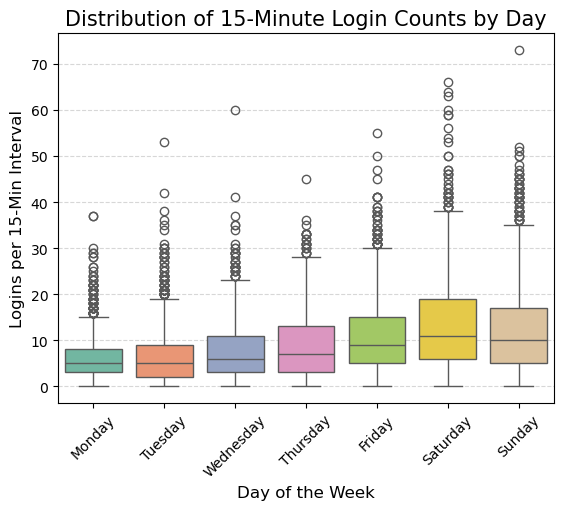

In [19]:
sns.boxplot(x='day_name', y='login_count', data=df_15min, order=day_order, palette='Set2')

plt.title('Distribution of 15-Minute Login Counts by Day', fontsize=15)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Logins per 15-Min Interval', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## Monthly Login Check

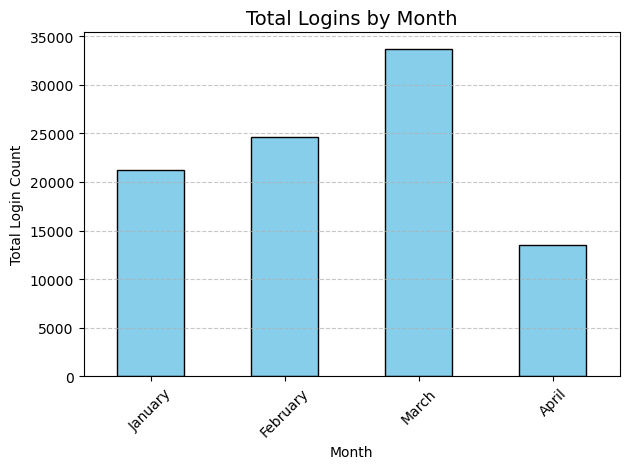

In [20]:
df_monthly = df_15min.groupby('month_name')['login_count'].sum()

month_order = ['January', 'February', 'March', 'April']
df_monthly = df_monthly.reindex(month_order)

df_monthly.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Total Logins by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Login Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Data is only 4 months

C:\Users\benpe\AppData\Local\Temp\ipykernel_66372\209335297.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='month_name', y='login_count', data=df_15min, palette='Set2')


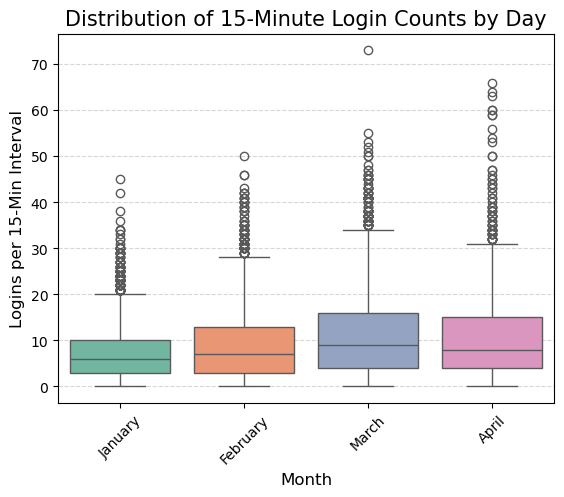

In [21]:
sns.boxplot(x='month_name', y='login_count', data=df_15min, palette='Set2')

plt.title('Distribution of 15-Minute Login Counts by Day', fontsize=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Logins per 15-Min Interval', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## Comparing Time of each Day

In [22]:
df_15min['hour'] = df_15min.index.hour
df_15min['day_name'] = df_15min.index.day_name()


pivot_table = df_15min.pivot_table(index='day_name', 
                                   columns='hour', 
                                   values='login_count', 
                                   aggfunc='mean')

pivot_table = pivot_table.reindex(day_order)
pivot_table.head()

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_name,,,,,,,,,,,,,,,,,,,,,
Monday,8.850000,6.900000,5.200000,3.933333,3.433333,2.016667,1.100000,1.850000,2.450000,4.266667,...,5.616667,4.883333,4.150000,3.966667,4.450000,4.678571,6.714286,10.803571,10.910714,9.500000
Tuesday,10.839286,10.107143,7.035714,3.535714,2.660714,2.017857,0.821429,1.142857,1.571429,4.321429,...,5.517857,4.410714,3.910714,3.267857,5.410714,5.375000,8.714286,12.571429,13.535714,12.928571
Wednesday,12.267857,12.250000,8.607143,5.339286,4.375000,2.410714,0.857143,1.500000,1.767857,4.285714,...,5.696429,4.696429,3.821429,3.428571,5.125000,5.464286,8.928571,13.196429,15.803571,16.214286
Thursday,14.571429,13.875000,11.160714,6.696429,4.553571,2.428571,1.196429,1.446429,1.696429,4.482143,...,6.928571,5.000000,4.321429,4.142857,6.267857,7.000000,10.366667,14.500000,18.150000,17.216667
Friday,16.250000,15.950000,12.850000,8.366667,5.883333,4.083333,2.016667,1.750000,1.816667,4.000000,...,8.700000,6.500000,6.200000,8.000000,9.616667,10.966667,13.383333,20.100000,25.316667,21.633333


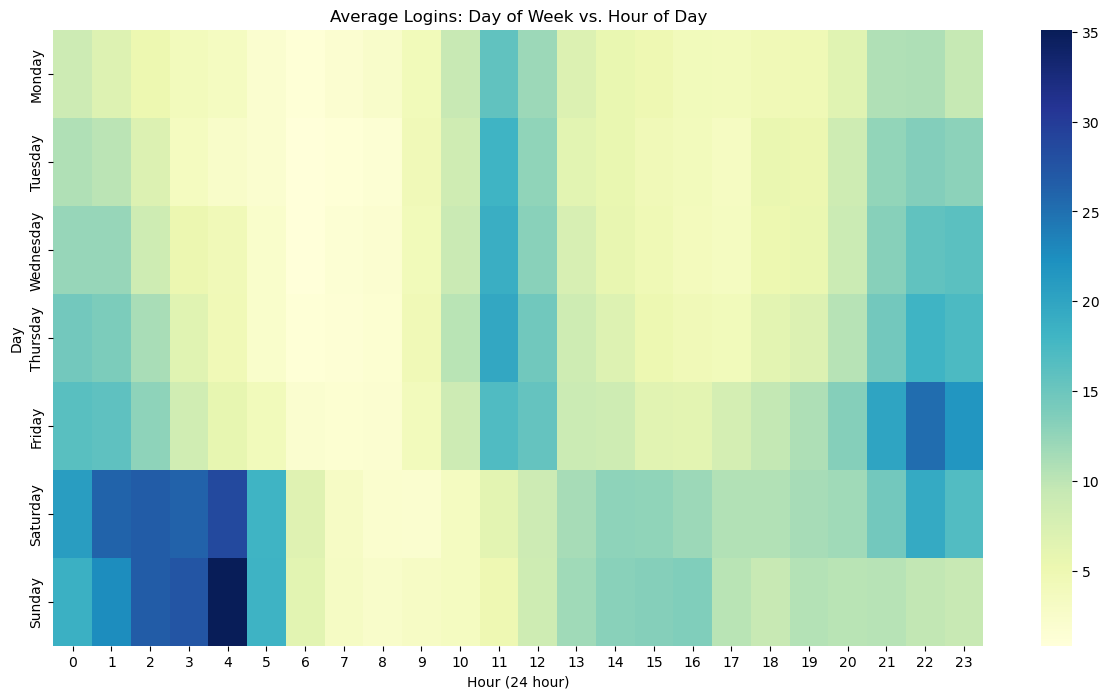

In [23]:
plt.figure(figsize=(15, 8))
sns.heatmap(pivot_table, annot=False, cmap='YlGnBu')
plt.title('Average Logins: Day of Week vs. Hour of Day')
plt.xlabel('Hour (24 hour)')
plt.ylabel('Day')
plt.show()

# Looks like there are more logins on the weekend ealry in the morning and night while during the week, 
# we see a larger increase of logins during the day.

In [24]:
anova_data = df_15min[['login_count', 'day_name', 'hour']]

# 2. Run the model
import statsmodels.api as sm
from statsmodels.formula.api import ols

# We tell the model: "Predict login_count based on the Day and the Hour"
model = ols('login_count ~ C(day_name) + C(hour)', data=anova_data).fit()
table = sm.stats.anova_lm(model, typ=2)

print(table)

                    sum_sq      df           F         PR(>F)
C(day_name)   67359.485891     6.0  255.769800  7.074029e-305
C(hour)      182945.865115    23.0  181.215989   0.000000e+00
Residual     428310.837420  9758.0         NaN            NaN


In [25]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. Run the test
# login_count is your 'y', day_name is your 'group'
tukey = pairwise_tukeyhsd(endog=df_15min['login_count'],
                          groups=df_15min['day_name'],
                          alpha=0.001)

print(tukey.summary())

   Multiple Comparison of Means - Tukey HSD, FWER=0.00   
 group1    group2  meandiff p-adj   lower   upper  reject
---------------------------------------------------------
  Friday    Monday  -4.3477    0.0 -5.5461 -3.1494   True
  Friday  Saturday   2.8951    0.0   1.701  4.0893   True
  Friday    Sunday   2.0549    0.0  0.8607   3.249   True
  Friday  Thursday   -1.767    0.0 -2.9786 -0.5554   True
  Friday   Tuesday  -3.6653    0.0 -4.8806   -2.45   True
  Friday Wednesday  -2.8684    0.0 -4.0837 -1.6531   True
  Monday  Saturday   7.2429    0.0  6.0445  8.4412   True
  Monday    Sunday   6.4026    0.0  5.2042  7.6009   True
  Monday  Thursday   2.5807    0.0   1.365  3.7965   True
  Monday   Tuesday   0.6825 0.2595  -0.537  1.9019  False
  Monday Wednesday   1.4793    0.0  0.2599  2.6987   True
Saturday    Sunday  -0.8403 0.0657 -2.0344  0.3539  False
Saturday  Thursday  -4.6621    0.0 -5.8737 -3.4505   True
Saturday   Tuesday  -6.5604    0.0 -7.7757 -5.3451   True
Saturday Wedne

# Part 2: Experiment and metrics design

## The Problem

The neighboring cities of Gotham and Metropolis have complementary circadian rhythms: on
weekdays, Ultimate Gotham is most active at night, and Ultimate Metropolis is most active
during the day. On weekends, there is reasonable activity in both cities.
However, a toll bridge, with a two way toll, between the two cities causes driver partners to tend
to be exclusive to each city. The Ultimate managers of city operations for the two cities have
proposed an experiment to encourage driver partners to be available in both cities, by
reimbursing all toll costs.
1) What would you choose as the key measure of success of this experiment in
encouraging driver partners to serve both cities, and why would you choose this metric?
2) Describe a practical experiment you would design to compare the effectiveness of the
proposed change in relation to the key measure of success. Please provide details on:
a) how you will implement the experiment
b) what statistical test(s) you will conduct to verify the significance of the
observation
c) how you would interpret the results and provide recommendations to the city
operations team along with any caveats.
Note: The two cities of Gotham and Metropolis are not in the provided dataset; however, you do
not need this information to answer Part 2

## Goals

The general goal is to determine if reimbursing all total costs for bridge crossing will encourage drivers to serve both cities.

- Determine key metric to measure success
- How to empliment experiment
- How to test experiment
- Interpret results
- Provide recommendation based on findings

## Experimental Design

Hypothesis - If the bridge is more accessible to the drivers (all tolls paid) then the drivers from each city will work more often in the other city, especially when the other city is busy. Specifically, when Gotham is busy at night (weekday), we would see an increase in drivers from Metropolis driving in Gotham and the opposite is true for Metropolis during the day (weekday). During the weekend, the where the driver's work will likely stay the same because they are closeer to where it is busy.

Null Hypothesis - There is not difference between paying tolls or not in where the drivers drive. 

Key Metric - Total trips in opposite city / Total trips for specific driver
limitation of metric - normalizes between driver that does many trips vs ones that may not do as many trips.

Experiment emplimentation - Note: this heavily depends on the data that is given. First the key metric would need to be calculated form the data at hand. This may be done by summing the total trips for each driver individually, and then dividing the total trips in their opposite city by the total trips to get the key metric. From there, a comparison between the mean, median, and other metrics of the ratio of trips in other cities would need to be compared for before and after the tolls are paid. This would include an hourly, daily, and a combination of the two features to determine if there is a difference in where where drivers are driving. It would be expected that during the week, most drivers would be in gotham at night and Metropolis during the day. On the weekend, a difference is not expected. When this trend is noticed, then the weekday data could be separated form weekend. Then a Paired Students T Test could be used to determine if the drivers ratios changed before and after the tolls were paid. The same dcould be done with the weekend data. 

Expected outcomes and advice -
Success - A difference is found (P< 0.05) between the before and after tolls being paid and before the benefit suggesting drivers are more willing to drive in both cities. I would suggest keeping the benefit for drivers if this is the case.
Fail - No difference was observed. I would not suggest keeping the benefit change. 
Expected - A weekday difference is expected, but the weekend difference is not because drivers are living near where bussiness is located and there is not benefit in driving further. For this scenario, i would recommend keeping the benefit durign the week and removing for the weekend. 

# Part 3: Predictive modeling

## The Problem

Ultimate is interested in predicting rider retention. To help explore this question, we have
provided a sample dataset of a cohort of users who signed up for an Ultimate account in
January 2014. The data was pulled several months later; we consider a user retained if they
were “active” (i.e. took a trip) in the preceding 30 days.
We would like you to use this data set to help understand what factors are the best predictors
for retention, and offer suggestions to operationalize those insights to help Ultimate.
The data is in the attached file ultimate_data_challenge.json. See below for a detailed
description of the dataset. Please include any code you wrote for the analysis and delete the
dataset when you have finished with the challenge.
1. Perform any cleaning, exploratory analysis, and/or visualizations to use the provided
data for this analysis (a few sentences/plots describing your approach will suffice). What
fraction of the observed users were retained?
2. Build a predictive model to help Ultimate determine whether or not a user will be active in
their 6th month on the system. Discuss why you chose your approach, what alternatives
you considered, and any concerns you have. How valid is your model? Include any key
indicators of model performance.
3. Briefly discuss how Ultimate might leverage the insights gained from the model to
improve its long term rider retention (again, a few sentences will suffice).

## Summary of Findings

Cleaning and EDA: I took a methodical and approach to remove null values (filled phone types with "Other", and numeric columns were filled with the median), determine a boolean feature showing retention. Then features containing dates were removed for better model performance. It was found that 37.6% of riders were retained.

Modeling: This is a classification issue so any ind of regression modeling was removed from consideration. A linear classification was considered as an initial baseline to compare other models to, but was skipped for time (Also would not give important features).I focused on Random forest and XGBoost as they are able to handle a variety of different types of data that are both numeric and categorical. They also give information about the importance of each feature. After a random grid search for optimization of both models, the XGBoost was found to be the most robust with a recall(Retained) of 78%, an f1 score of 0.72, and an overall accuracy of 78% for the test dataset. The three most important features for rider given by the XGBoost model were city-King's Landing, Average rating by driver, and if they use an iphone. 

Data Concerns: Data Sparcity - There were many reviews not filled out leaving it necessary to use the median to fill in any missing values. If there are pricing changes or other business alterations, then the model will likely need to be reoptimized and may not be able to be used for forecasting. 

Bussiness insights: You may want to look into why there has been such success in King's Landing. This may give you further insights into what you can do to improve success elsewhere. The average rating by driver is interesting but I think it relates to the interaction with the customer that may bring the customer back. The use of iphone being advantageous may actually relate to the app itself and so development may be waranted. 

In [26]:
# import relevant libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Splitting Data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [27]:
# load the data
df2 = pd.read_json(r"C:\Users\benpe\OneDrive\Documents\GitHub\Projects\1631809090_1481053515_ultimate_challenge_3_ (1)\ultimate_challenge\ultimate_data_challenge.json")
df2.head(10)

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
0,King's Landing,4,2014-01-25,4.7,1.10,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0
1,Astapor,0,2014-01-29,5.0,1.00,2014-05-05,Android,0.0,False,50.0,8.26,5.0
2,Astapor,3,2014-01-06,4.3,1.00,2014-01-07,iPhone,0.0,False,100.0,0.77,5.0
3,King's Landing,9,2014-01-10,4.6,1.14,2014-06-29,iPhone,20.0,True,80.0,2.36,4.9
4,Winterfell,14,2014-01-27,4.4,1.19,2014-03-15,Android,11.8,False,82.4,3.13,4.9
5,Winterfell,2,2014-01-09,3.5,1.00,2014-06-06,iPhone,0.0,True,100.0,10.56,5.0
6,Astapor,1,2014-01-24,NaN,1.00,2014-01-25,Android,0.0,False,100.0,3.95,4.0
7,Winterfell,2,2014-01-28,5.0,1.00,2014-01-29,iPhone,0.0,False,100.0,2.04,5.0
8,Winterfell,2,2014-01-21,4.5,1.00,2014-02-01,Android,0.0,False,100.0,4.36,5.0
9,Winterfell,1,2014-01-03,NaN,1.00,2014-01-05,Android,0.0,False,0.0,2.37,5.0


## Data Cleaning

In [28]:
df2.describe()

,trips_in_first_30_days,avg_rating_of_driver,avg_surge,surge_pct,weekday_pct,avg_dist,avg_rating_by_driver
count,50000.000000,41878.000000,50000.000000,50000.000000,50000.000000,50000.000000,49799.000000
mean,2.278200,4.601559,1.074764,8.849536,60.926084,5.796827,4.778158
std,3.792684,0.617338,0.222336,19.958811,37.081503,5.707357,0.446652
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,4.300000,1.000000,0.000000,33.300000,2.420000,4.700000
50%,1.000000,4.900000,1.000000,0.000000,66.700000,3.880000,5.000000
75%,3.000000,5.000000,1.050000,8.600000,100.000000,6.940000,5.000000
max,125.000000,5.000000,8.000000,100.000000,100.000000,160.960000,5.000000


In [29]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    50000 non-null  object 
 1   trips_in_first_30_days  50000 non-null  int64  
 2   signup_date             50000 non-null  object 
 3   avg_rating_of_driver    41878 non-null  float64
 4   avg_surge               50000 non-null  float64
 5   last_trip_date          50000 non-null  object 
 6   phone                   49604 non-null  object 
 7   surge_pct               50000 non-null  float64
 8   ultimate_black_user     50000 non-null  bool   
 9   weekday_pct             50000 non-null  float64
 10  avg_dist                50000 non-null  float64
 11  avg_rating_by_driver    49799 non-null  float64
dtypes: bool(1), float64(6), int64(1), object(4)
memory usage: 4.2+ MB


In [30]:
df2.isnull().sum()

city                         0
trips_in_first_30_days       0
signup_date                  0
avg_rating_of_driver      8122
avg_surge                    0
last_trip_date               0
phone                      396
surge_pct                    0
ultimate_black_user          0
weekday_pct                  0
avg_dist                     0
avg_rating_by_driver       201
dtype: int64

In [31]:
df2.duplicated().sum()

np.int64(8)

In [32]:
df2['phone'].unique()

# The nones might just be other types of phones and since they need a phone to order a ride, I'll just put other.

array(['iPhone', 'Android', None], dtype=object)

In [33]:
df2['phone'] = df2['phone'].fillna('Other')
df2['phone'].unique()

array(['iPhone', 'Android', 'Other'], dtype=object)

In [34]:
df2.isnull().sum()

city                         0
trips_in_first_30_days       0
signup_date                  0
avg_rating_of_driver      8122
avg_surge                    0
last_trip_date               0
phone                        0
surge_pct                    0
ultimate_black_user          0
weekday_pct                  0
avg_dist                     0
avg_rating_by_driver       201
dtype: int64

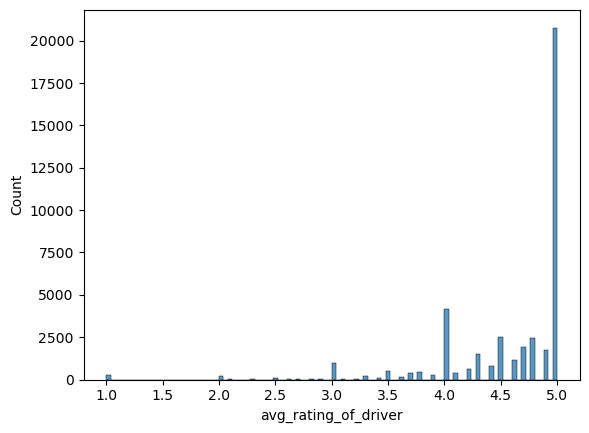

In [35]:
# Now for the avg_rating_of_driver
sns.histplot(df2['avg_rating_of_driver'])
plt.show()

In [36]:
df2['avg_rating_of_driver'].unique()


array([4.7, 5. , 4.3, 4.6, 4.4, 3.5, nan, 4.5, 4. , 3.9, 4.9, 4.8, 2.5,
       3.7, 1. , 4.1, 4.2, 3. , 3.8, 2. , 2.7, 3.3, 2.8, 3.6, 3.4, 3.2,
       2.6, 3.1, 2.9, 1.7, 1.8, 1.5, 2.3, 1.9, 2.1, 2.4, 1.6, 2.2])

In [37]:
print(f"The median is: {df2['avg_rating_of_driver'].median()}")
print(f"The mean is: {df2['avg_rating_of_driver'].mean()}")

# The median seems to be closeer to the larger set of data so the median will be used

The median is: 4.9
The mean is: 4.601559291274655


In [38]:
df2['avg_rating_of_driver'] = df2['avg_rating_of_driver'].fillna(df2['avg_rating_of_driver'].median())
df2['avg_rating_of_driver'].unique()

array([4.7, 5. , 4.3, 4.6, 4.4, 3.5, 4.9, 4.5, 4. , 3.9, 4.8, 2.5, 3.7,
       1. , 4.1, 4.2, 3. , 3.8, 2. , 2.7, 3.3, 2.8, 3.6, 3.4, 3.2, 2.6,
       3.1, 2.9, 1.7, 1.8, 1.5, 2.3, 1.9, 2.1, 2.4, 1.6, 2.2])

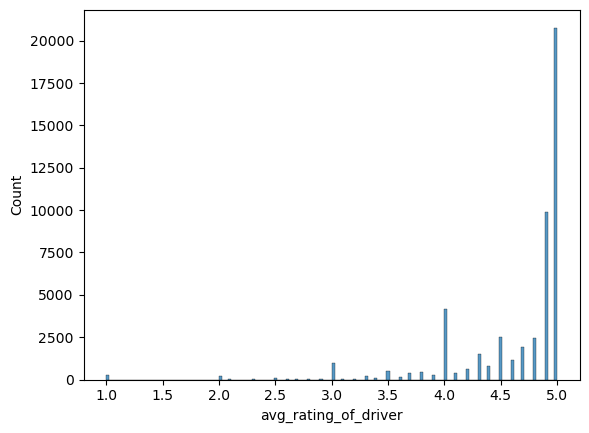

In [39]:
sns.histplot(df2['avg_rating_of_driver'])
plt.show()

# looks like much more 4.9 was added as expected

In [40]:
df2.isnull().sum()

city                        0
trips_in_first_30_days      0
signup_date                 0
avg_rating_of_driver        0
avg_surge                   0
last_trip_date              0
phone                       0
surge_pct                   0
ultimate_black_user         0
weekday_pct                 0
avg_dist                    0
avg_rating_by_driver      201
dtype: int64

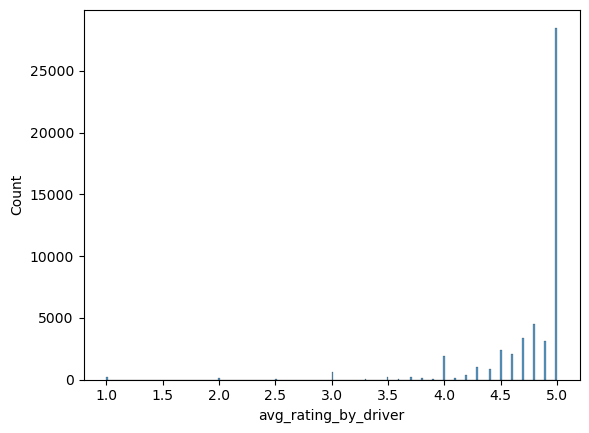

In [41]:
# Avg rating by driver
sns.histplot(df2['avg_rating_by_driver'])
plt.show()

In [42]:
df2['avg_rating_by_driver'].unique()

array([5. , 4.9, 4. , 3. , 4.8, 4.7, 4.5, 4.2, nan, 4.4, 4.6, 3.7, 4.3,
       3.5, 2. , 3.8, 2.5, 4.1, 3.9, 1. , 3.3, 3.4, 3.6, 3.2, 2.3, 2.8,
       1.5, 2.7])

In [43]:
print(f"The median is: {df2['avg_rating_by_driver'].median()}")
print(f"The mean is: {df2['avg_rating_by_driver'].mean()}")

# The median seems to be closeer to the larger set of data so the median will be used

The median is: 5.0
The mean is: 4.77815819594771


In [44]:
df2['avg_rating_by_driver'] = df2['avg_rating_by_driver'].fillna(df2['avg_rating_by_driver'].median())
df2['avg_rating_by_driver'].unique()

array([5. , 4.9, 4. , 3. , 4.8, 4.7, 4.5, 4.2, 4.4, 4.6, 3.7, 4.3, 3.5,
       2. , 3.8, 2.5, 4.1, 3.9, 1. , 3.3, 3.4, 3.6, 3.2, 2.3, 2.8, 1.5,
       2.7])

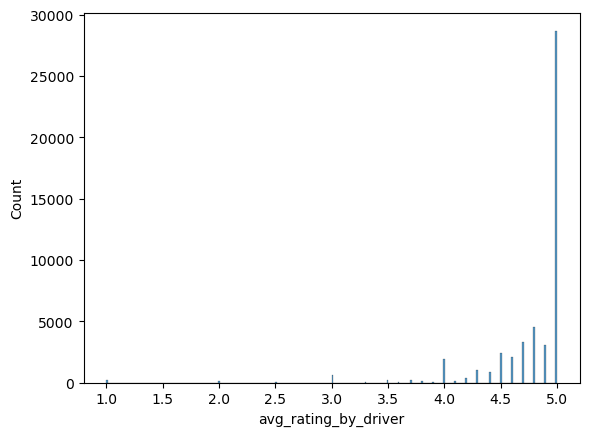

In [45]:
sns.histplot(df2['avg_rating_by_driver'])
plt.show()

# looks like much more 5 was added as expected

In [46]:
df2.isnull().sum()

city                      0
trips_in_first_30_days    0
signup_date               0
avg_rating_of_driver      0
avg_surge                 0
last_trip_date            0
phone                     0
surge_pct                 0
ultimate_black_user       0
weekday_pct               0
avg_dist                  0
avg_rating_by_driver      0
dtype: int64

In [47]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    50000 non-null  object 
 1   trips_in_first_30_days  50000 non-null  int64  
 2   signup_date             50000 non-null  object 
 3   avg_rating_of_driver    50000 non-null  float64
 4   avg_surge               50000 non-null  float64
 5   last_trip_date          50000 non-null  object 
 6   phone                   50000 non-null  object 
 7   surge_pct               50000 non-null  float64
 8   ultimate_black_user     50000 non-null  bool   
 9   weekday_pct             50000 non-null  float64
 10  avg_dist                50000 non-null  float64
 11  avg_rating_by_driver    50000 non-null  float64
dtypes: bool(1), float64(6), int64(1), object(4)
memory usage: 4.2+ MB


In [48]:
df_all_dupes = df2[df2.duplicated(keep=False)]

df_all_dupes.sort_values(by=['signup_date', 'avg_dist']).head(10)

# looks like these could be multiple tirps in a day, but since its 8 outs of the 50000 samples that did that, then they are likely mistakes. 

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
26709,Winterfell,1,2014-01-01,4.9,1.0,2014-01-02,Android,0.0,False,100.0,8.08,5.0
29601,Winterfell,1,2014-01-01,4.9,1.0,2014-01-02,Android,0.0,False,100.0,8.08,5.0
116,Winterfell,1,2014-01-10,5.0,1.0,2014-01-11,Android,0.0,False,100.0,0.00,5.0
39601,Winterfell,1,2014-01-10,5.0,1.0,2014-01-11,Android,0.0,False,100.0,0.00,5.0
7836,Astapor,1,2014-01-11,5.0,1.0,2014-01-11,iPhone,0.0,True,0.0,2.33,5.0
18057,Astapor,1,2014-01-11,5.0,1.0,2014-01-11,iPhone,0.0,True,0.0,2.33,5.0
5958,Winterfell,1,2014-01-18,4.9,1.0,2014-01-19,Android,0.0,False,0.0,0.01,5.0
42025,Winterfell,1,2014-01-18,4.9,1.0,2014-01-19,Android,0.0,False,0.0,0.01,5.0
14990,Winterfell,1,2014-01-18,4.9,1.0,2014-01-19,iPhone,0.0,True,0.0,1.44,5.0
34641,Winterfell,1,2014-01-18,4.9,1.0,2014-01-19,iPhone,0.0,True,0.0,1.44,5.0


In [49]:
df2 = df2.drop_duplicates()
df2.duplicated().sum()

np.int64(0)

In [50]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49992 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    49992 non-null  object 
 1   trips_in_first_30_days  49992 non-null  int64  
 2   signup_date             49992 non-null  object 
 3   avg_rating_of_driver    49992 non-null  float64
 4   avg_surge               49992 non-null  float64
 5   last_trip_date          49992 non-null  object 
 6   phone                   49992 non-null  object 
 7   surge_pct               49992 non-null  float64
 8   ultimate_black_user     49992 non-null  bool   
 9   weekday_pct             49992 non-null  float64
 10  avg_dist                49992 non-null  float64
 11  avg_rating_by_driver    49992 non-null  float64
dtypes: bool(1), float64(6), int64(1), object(4)
memory usage: 4.6+ MB


In [51]:
# need to convert some datatypes

df2['last_trip_date'] = pd.to_datetime(df2['last_trip_date'])

df2['signup_date'] = pd.to_datetime(df2['signup_date'])

In [52]:
# must now create the retained label so i need to know when is the most recent date and then grab the data that is 30 days form then

df2['last_trip_date'].max()


Timestamp('2014-07-01 00:00:00')

In [53]:
# need to make the cutoff
df2_cutoff = pd.Timestamp('2014-06-01')

# next to label the new column
df2['retained'] = df2['last_trip_date'].apply(lambda x: 1 if x >= df2_cutoff else 0)
df2.head()

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver,retained
0,King's Landing,4,2014-01-25,4.7,1.10,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0,1
1,Astapor,0,2014-01-29,5.0,1.00,2014-05-05,Android,0.0,False,50.0,8.26,5.0,0
2,Astapor,3,2014-01-06,4.3,1.00,2014-01-07,iPhone,0.0,False,100.0,0.77,5.0,0
3,King's Landing,9,2014-01-10,4.6,1.14,2014-06-29,iPhone,20.0,True,80.0,2.36,4.9,1
4,Winterfell,14,2014-01-27,4.4,1.19,2014-03-15,Android,11.8,False,82.4,3.13,4.9,0


In [54]:
print(df2['retained'].value_counts(normalize=True))

# only 37% of the riders were retained!

retained
0    0.62386
1    0.37614
Name: proportion, dtype: float64


In [55]:
# need to remove last trip data to prevent data leakage

df2 = df2.drop('last_trip_date', axis=1)
df2.columns

Index(['city', 'trips_in_first_30_days', 'signup_date', 'avg_rating_of_driver',
       'avg_surge', 'phone', 'surge_pct', 'ultimate_black_user', 'weekday_pct',
       'avg_dist', 'avg_rating_by_driver', 'retained'],
      dtype='object')

In [56]:
# Want to remove signup date, so now changing it to days since signup.
max_date = pd.Timestamp('2014-07-01 00:00:00')

df2['days_since_signup'] = (max_date - df2['signup_date']).dt.days

df2[['signup_date', 'days_since_signup']].head()

,signup_date,days_since_signup
0,2014-01-25,157
1,2014-01-29,153
2,2014-01-06,176
3,2014-01-10,172
4,2014-01-27,155


In [57]:
df2 = df2.drop('signup_date', axis=1)
df2.columns

Index(['city', 'trips_in_first_30_days', 'avg_rating_of_driver', 'avg_surge',
       'phone', 'surge_pct', 'ultimate_black_user', 'weekday_pct', 'avg_dist',
       'avg_rating_by_driver', 'retained', 'days_since_signup'],
      dtype='object')

In [58]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49992 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    49992 non-null  object 
 1   trips_in_first_30_days  49992 non-null  int64  
 2   avg_rating_of_driver    49992 non-null  float64
 3   avg_surge               49992 non-null  float64
 4   phone                   49992 non-null  object 
 5   surge_pct               49992 non-null  float64
 6   ultimate_black_user     49992 non-null  bool   
 7   weekday_pct             49992 non-null  float64
 8   avg_dist                49992 non-null  float64
 9   avg_rating_by_driver    49992 non-null  float64
 10  retained                49992 non-null  int64  
 11  days_since_signup       49992 non-null  int64  
dtypes: bool(1), float64(6), int64(3), object(2)
memory usage: 4.6+ MB


In [59]:
df2['city'].unique()

array(["King's Landing", 'Astapor', 'Winterfell'], dtype=object)

## Preparing the Data for Modeling

In [60]:
# time to encode the city, phone, and black user columns columns
df_encoded = pd.get_dummies(df2, columns=['city', 'phone', 'ultimate_black_user'], drop_first=True)
df_encoded.head()

,trips_in_first_30_days,avg_rating_of_driver,avg_surge,surge_pct,weekday_pct,avg_dist,avg_rating_by_driver,retained,days_since_signup,city_King's Landing,city_Winterfell,phone_Other,phone_iPhone,ultimate_black_user_True
0,4,4.7,1.10,15.4,46.2,3.67,5.0,1,157,True,False,False,True,True
1,0,5.0,1.00,0.0,50.0,8.26,5.0,0,153,False,False,False,False,False
2,3,4.3,1.00,0.0,100.0,0.77,5.0,0,176,False,False,False,True,False
3,9,4.6,1.14,20.0,80.0,2.36,4.9,1,172,True,False,False,True,True
4,14,4.4,1.19,11.8,82.4,3.13,4.9,0,155,False,True,False,False,False


In [61]:
# Next is to split the data
X = df_encoded.drop('retained', axis=1)
y = df_encoded['retained'].astype(bool)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [62]:
X_train.head()

,trips_in_first_30_days,avg_rating_of_driver,avg_surge,surge_pct,weekday_pct,avg_dist,avg_rating_by_driver,days_since_signup,city_King's Landing,city_Winterfell,phone_Other,phone_iPhone,ultimate_black_user_True
40345,1,5.0,1.0,0.0,100.0,4.85,5.0,165,False,False,False,False,False
40758,0,4.9,1.0,0.0,100.0,15.11,5.0,156,False,True,False,True,False
49075,2,5.0,1.0,0.0,11.1,1.36,4.9,156,False,False,False,True,True
44868,5,4.8,1.2,31.3,56.3,2.74,5.0,158,True,False,False,True,True
16441,1,4.5,1.0,0.0,85.7,3.67,5.0,156,False,False,False,True,False


In [63]:
y_train.head()

40345    False
40758     True
49075     True
44868     True
16441    False
Name: retained, dtype: bool

In [64]:
X_test.head()

,trips_in_first_30_days,avg_rating_of_driver,avg_surge,surge_pct,weekday_pct,avg_dist,avg_rating_by_driver,days_since_signup,city_King's Landing,city_Winterfell,phone_Other,phone_iPhone,ultimate_black_user_True
6476,6,4.7,1.01,5.3,73.7,3.43,4.9,155,False,False,False,True,True
5201,2,4.9,1.25,50.0,100.0,3.62,5.0,161,False,False,False,False,False
49169,2,5.0,1.75,50.0,100.0,1.64,5.0,159,False,True,False,True,False
35836,0,5.0,1.00,0.0,100.0,3.16,5.0,181,False,True,False,True,False
38141,2,5.0,1.00,0.0,76.5,2.29,4.8,181,False,True,False,False,False


In [65]:
y_test.head()

6476      True
5201     False
49169    False
35836    False
38141    False
Name: retained, dtype: bool

In [66]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39993 entries, 40345 to 39274
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   trips_in_first_30_days    39993 non-null  int64  
 1   avg_rating_of_driver      39993 non-null  float64
 2   avg_surge                 39993 non-null  float64
 3   surge_pct                 39993 non-null  float64
 4   weekday_pct               39993 non-null  float64
 5   avg_dist                  39993 non-null  float64
 6   avg_rating_by_driver      39993 non-null  float64
 7   days_since_signup         39993 non-null  int64  
 8   city_King's Landing       39993 non-null  bool   
 9   city_Winterfell           39993 non-null  bool   
 10  phone_Other               39993 non-null  bool   
 11  phone_iPhone              39993 non-null  bool   
 12  ultimate_black_user_True  39993 non-null  bool   
dtypes: bool(5), float64(6), int64(2)
memory usage: 2.9 MB


In [67]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9999 entries, 6476 to 22531
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   trips_in_first_30_days    9999 non-null   int64  
 1   avg_rating_of_driver      9999 non-null   float64
 2   avg_surge                 9999 non-null   float64
 3   surge_pct                 9999 non-null   float64
 4   weekday_pct               9999 non-null   float64
 5   avg_dist                  9999 non-null   float64
 6   avg_rating_by_driver      9999 non-null   float64
 7   days_since_signup         9999 non-null   int64  
 8   city_King's Landing       9999 non-null   bool   
 9   city_Winterfell           9999 non-null   bool   
 10  phone_Other               9999 non-null   bool   
 11  phone_iPhone              9999 non-null   bool   
 12  ultimate_black_user_True  9999 non-null   bool   
dtypes: bool(5), float64(6), int64(2)
memory usage: 751.9 KB


In [68]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 39993 entries, 40345 to 39274
Series name: retained
Non-Null Count  Dtype
--------------  -----
39993 non-null  bool 
dtypes: bool(1)
memory usage: 351.5 KB


In [69]:
y_test.info()

<class 'pandas.core.series.Series'>
Index: 9999 entries, 6476 to 22531
Series name: retained
Non-Null Count  Dtype
--------------  -----
9999 non-null   bool 
dtypes: bool(1)
memory usage: 87.9 KB


In [70]:
# will scale despite wanting to use random forest. This will ssave steps if more models are needed later such as a linear fit.

scaler = StandardScaler()

cols_to_scale = ['avg_dist', 'avg_rating_by_driver', 'avg_rating_of_driver', 
                 'avg_surge', 'surge_pct', 'trips_in_first_30_days', 
                 'weekday_pct', 'days_since_signup']

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [71]:
X_train.describe()

,trips_in_first_30_days,avg_rating_of_driver,avg_surge,surge_pct,weekday_pct,avg_dist,avg_rating_by_driver,days_since_signup
count,3.999300e+04,3.999300e+04,3.999300e+04,3.999300e+04,3.999300e+04,3.999300e+04,3.999300e+04,3.999300e+04
mean,-4.548269e-17,-6.385344e-16,2.339871e-16,-6.964538e-17,1.161941e-16,6.147270e-17,-2.768048e-16,-3.134042e-16
std,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00
min,-6.023655e-01,-6.326683e+00,-3.376862e-01,-4.443884e-01,-1.639550e+00,-1.028192e+00,-8.464833e+00,-1.651834e+00
25%,-6.023655e-01,-2.577286e-01,-3.376862e-01,-4.443884e-01,-7.424684e-01,-5.963047e-01,-1.756055e-01,-8.518345e-01
50%,-3.383205e-01,4.358662e-01,-3.376862e-01,-4.443884e-01,1.573069e-01,-3.368169e-01,4.964940e-01,-5.183477e-02
75%,1.897693e-01,6.092649e-01,-1.116793e-01,-4.288598e-03,1.054388e+00,2.052639e-01,4.964940e-01,8.624507e-01
max,3.240325e+01,6.092649e-01,3.130327e+01,4.556745e+00,1.054388e+00,2.205734e+01,4.964940e-01,1.776736e+00


## Modeling

Due to time constraints, this will focus on Random Forest and XGBoost. Normally I would also add a linear classifier to as a baseline sanity check. 

Since this is a classification problem, precision and recall (f1) will be the primary metrics for success

In [72]:
# Import models

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, accuracy_score

### Random Forest

In [73]:
# Basic rf

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)
y_train_rf = rf.predict(X_train)
print("--- Random Forest Performance Testing Set---")
print(classification_report(y_test, y_pred_rf))

print("--- Random Forest Performance Training Set---")
print(classification_report(y_train, y_train_rf))

# Overfit

--- Random Forest Performance Testing Set---
              precision    recall  f1-score   support

       False       0.80      0.84      0.82      6238
        True       0.71      0.65      0.68      3761

    accuracy                           0.77      9999
   macro avg       0.76      0.75      0.75      9999
weighted avg       0.77      0.77      0.77      9999

--- Random Forest Performance Training Set---
              precision    recall  f1-score   support

       False       1.00      1.00      1.00     24950
        True       1.00      1.00      1.00     15043

    accuracy                           1.00     39993
   macro avg       1.00      1.00      1.00     39993
weighted avg       1.00      1.00      1.00     39993



In [84]:
# only doing a single optimization round due to time

param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [2, 5, 10, 20, 30, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False],
    'class_weight': ['balanced', 'balanced_subsample']
}


rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=30, 
    cv=5, 
    scoring='f1', 
    n_jobs=-1, 
    random_state=42,
    verbose=1
)

# 3. Fit it
rf_random.fit(X_train, y_train)

print(f"Best Score: {rf_random.best_score_}")
print(f"Best Params: {rf_random.best_params_}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Score: 0.7170414180347475
Best Params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': 'log2', 'max_depth': 20, 'class_weight': 'balanced', 'bootstrap': True}


In [85]:
best_model = rf_random.best_estimator_
y_pred_rf_opt = best_model.predict(X_train)

print("----RF Random GridSearch Optimized Train----")
print(classification_report(y_train, y_pred_rf_opt))

y_pred = best_model.predict(X_test)
print("----RF Random GridSearch Optimized Test----")
print(classification_report(y_test, y_pred))

----RF Random GridSearch Optimized Train----
              precision    recall  f1-score   support

       False       0.88      0.84      0.86     24950
        True       0.75      0.81      0.78     15043

    accuracy                           0.83     39993
   macro avg       0.82      0.82      0.82     39993
weighted avg       0.83      0.83      0.83     39993

----RF Random GridSearch Optimized Test----
              precision    recall  f1-score   support

       False       0.83      0.80      0.82      6238
        True       0.69      0.74      0.71      3761

    accuracy                           0.78      9999
   macro avg       0.76      0.77      0.77      9999
weighted avg       0.78      0.78      0.78      9999



<Axes: title={'center': 'Top 10 Predictors of Retention - Random Forest'}>

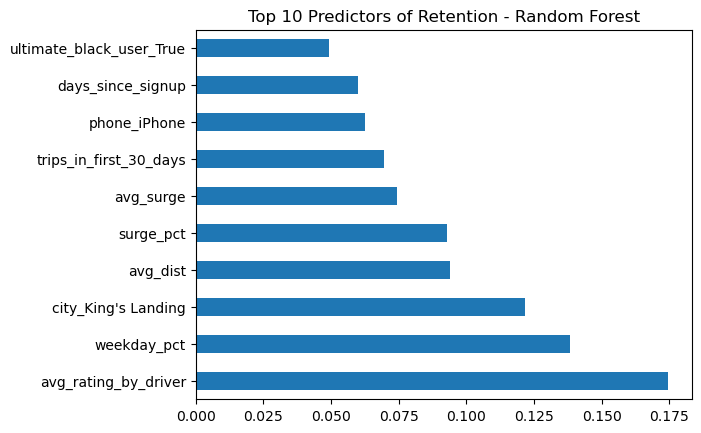

In [97]:
importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10).plot(kind='barh', title='Top 10 Predictors of Retention - Random Forest')

### XGBoost

In [79]:
xgb_model = XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5, 
    scale_pos_weight=1.7, 
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_train_xgb = xgb_model.predict(X_train
                               )
print("--- XGBoost Performance Test---")
print(classification_report(y_test, y_pred_xgb))

print("--- XGBoost Performance Train---")
print(classification_report(y_train, y_train_xgb))

--- XGBoost Performance Test---
              precision    recall  f1-score   support

       False       0.85      0.79      0.82      6238
        True       0.68      0.76      0.72      3761

    accuracy                           0.78      9999
   macro avg       0.77      0.78      0.77      9999
weighted avg       0.79      0.78      0.78      9999

--- XGBoost Performance Train---
              precision    recall  f1-score   support

       False       0.86      0.79      0.82     24950
        True       0.70      0.78      0.74     15043

    accuracy                           0.79     39993
   macro avg       0.78      0.79      0.78     39993
weighted avg       0.80      0.79      0.79     39993



In [86]:
param_dist_xgb = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.5],
    'max_depth': [3, 4, 5], 
    'colsample_bytree': [0.7, 0.8, 0.9],
    'subsample': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2, 0.5], 
    'scale_pos_weight': [1.5, 1.6, 1.7, 1.8, 1.9] 
}

xgb_random = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_distributions=param_dist_xgb,
    n_iter=30, 
    cv=5, 
    scoring='f1', 
    n_jobs=-1, 
    random_state=42,
    verbose=1
)


xgb_random.fit(X_train, y_train)

print(f"Best XGB Params: {xgb_random.best_params_}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best XGB Params: {'subsample': 0.7, 'scale_pos_weight': 1.9, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.8}


In [87]:
best_xgb = xgb_random.best_estimator_

print("---- XGB Optimized Train ----")
print(classification_report(y_train, best_xgb.predict(X_train)))

print("---- XGB Optimized Test ----")
print(classification_report(y_test, best_xgb.predict(X_test)))

---- XGB Optimized Train ----
              precision    recall  f1-score   support

       False       0.88      0.79      0.84     24950
        True       0.71      0.82      0.76     15043

    accuracy                           0.80     39993
   macro avg       0.79      0.81      0.80     39993
weighted avg       0.82      0.80      0.81     39993

---- XGB Optimized Test ----
              precision    recall  f1-score   support

       False       0.86      0.77      0.81      6238
        True       0.67      0.78      0.72      3761

    accuracy                           0.78      9999
   macro avg       0.76      0.78      0.77      9999
weighted avg       0.79      0.78      0.78      9999



<Axes: title={'center': 'Top 10 Predictors of Retention - XGBoost'}>

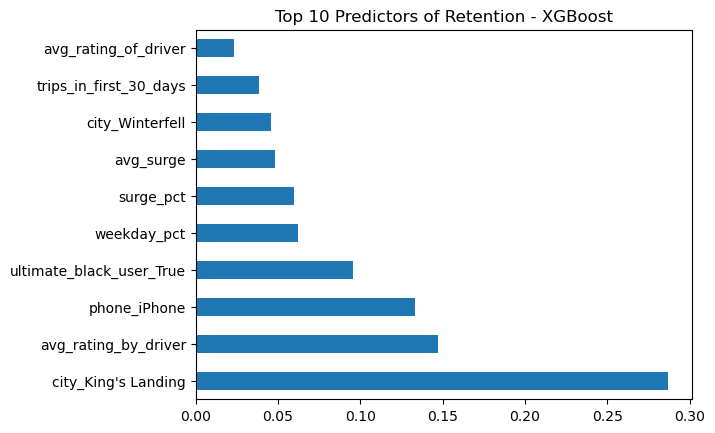

In [98]:
importances = pd.Series(best_xgb.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10).plot(kind='barh', title='Top 10 Predictors of Retention - XGBoost')